# Computing Thermal Normal Modes and Essential Dynamics from Trajectories


## Table of Content: <a name="TOC"></a>
1. [User-level approaches](#1)

   1.1. [PCA (Principal Component Analysis / Essential Dynamics)](#1.1)
   
   1.2. [Quasi-Harmonic Analysis (QHA)](#1.2)
   
   1.3. [Strachan Velocity-Based Modes](#1.3)
   
   1.4. [Strachan Acceleration-Based Modes](#1.4)
   
   1.5. [Pereverzev Finite-Temperature Hessian](#1.5)
   
   1.6. [Comparison of Methods](#1.6)
   
   1.7. [Exercises 1](#1.7)

2. [Step-by-step explanation of the procedure](#2)

   2.1. [Reading the trajectory](#2.1)
   
   2.2. [Converting atomic element names to masses](#2.2)
   
   2.3. [Computing covariance matrices](#2.3)
   
   2.4. [Solving the eigenvalue problem](#2.4)
   
   2.5. [Sorting frequencies and correspondingly the eigenvectors](#2.5)
   
   2.6. [Compute the Cartesian normal modes](#2.6)
   
   2.7. [Manipulating eigenvectors](#2.7)
   
   2.8. [Writing coordinates and normal mode vectors into XYZ files](#2.8)
   
   2.9. [Writing all normal modes into an ".nmd" file understood by VMD](#2.9)
   
   2.10. [Generating normal mode trajectories](#2.10)


## A. Learning objectives

- to conduct the PCA of atomic coordinate fluctuations
- to compute thermal normal modes and frequencies using quasiharmonic approximation
- to compute thermal normal modes and frequencies using velocities and coordinate fluctuations
- to compute thermal normal modes and frequencies using accelerations and coordinate fluctuations
- to compute thermal Hessian using force covariance matrix


## B. Use cases

- Analyzing MD trajectories
- Normal modes
- [Reading the trajectory](#2.1)
- [Computing covariance matrices](#2.3)
- [Sorting frequencies and correspondingly the eigenvectors](#2.5)
- [Compute the Cartesian normal modes](#2.6)
- [Writing coordinates and normal mode vectors into XYZ files](#2.8)
- [Writing all normal modes into an ".nmd" file understood by VMD](#2.9)
- [Generating normal mode trajectories](#2.10)


## C. Functions

- `libra_py`
  - `md_align`
    - [`align_trajectory`](#align_trajectory-1)
    - [`project_out_rigid`](#project_out_rigid-1)
  - `normal_modes`
    - [`compute_thermal_normal_modes`](#compute_thermal_normal_modes-1)
    - [`covariance_matrix`](#covariance_matrix-1)     
    - [`normal_modes_from_eigenvectors`](#normal_modes_from_eigenvectors-1)
    - [`visualize_modes`](#visualize_modes-1)
    - [`write_nmd`](#write_nmd-1)
  - `packages`
    - `xyz`
      - `methods`
        - [`names_to_masses`](#names_to_masses-1)
        - [`read_trajectory`](#read_trajectory-1)
        - [`write_trajectory`](#write_trajectory-1)


In [1]:
import math

from liblibra_core import *
import libra_py
import libra_py.units as units
import libra_py.md_align as md_align
import libra_py.packages.qe.methods as qe
import libra_py.packages.xyz.methods as xyz
import libra_py.normal_modes as nm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 1. User-level approaches 
[Back to TOC](#TOC)
<a name="1"></a>

Here, we will first consider different ways of computing different kinds of special motions and their frequencies or variances

### Notation and Definitions

Let:

- $N$ — number of atoms  
- $i,j \in \{1,\dots,3N\}$ — Cartesian degrees of freedom  
- $t$ — time index along an MD trajectory  
- $m_i$ — mass associated with degree of freedom $i$  
- $x_i(t)$ — Cartesian coordinate  
- $v_i(t) = \dot{x}_i(t)$ — velocity  
- $a_i(t) = \ddot{x}_i(t)$ — acceleration  
- $F_i(t) = -\partial V / \partial x_i$ — force  
- $\langle \cdot \rangle$ — ensemble (time) average  
- $\beta = (k_B T)^{-1}$ — inverse temperature  
- $\eta_k$ — mass-weighted eigenvector (normal mode)  
- $\Delta x_k$ — Cartesian normal-mode displacement  

Cartesian normal modes are obtained from mass-weighted eigenvectors via:

$$
\Delta x_k = M^{-1/2} \eta_k
$$

### Functions used:

- `xyz.read_trajectory` - for reading XYZ trajectory information (coordinates, velocities, forces, etc)
- `xyz.names_to_masses` - to define masses of atoms from their element names
- `nm.compute_thermal_normal_modes` - compute Cartesian normal modes from the mass-weighted eigenvectors
- `xyz.write_trajectory` - to write a trajectory or some snapshots of it into an XYZ file
- `nm.write_nmd` - to create the files with the normal modes information understood by the NMWizard of VMD

<a name="compute_thermal_normal_modes-1"></a>

In [2]:
help(nm.compute_thermal_normal_modes)

Help on function compute_thermal_normal_modes in module libra_py.normal_modes:

compute_thermal_normal_modes(R, M, method='QHA', V=None, A=None, F=None, temperature=None, remove_rigid=False)
    Unified covariance-based normal-mode analysis at finite temperature.
    
    This function implements several related but conceptually distinct
    normal-mode definitions based on covariance matrices sampled from MD.
    
    ----------------------------------------------------------------------
    METHODS IMPLEMENTED
    ----------------------------------------------------------------------
    
    PCA (Essential Dynamics)
    -----------------------
    Matrix:
        C^r_ij = < δr_i δr_j >
    
    Interpretation:
        Eigenvectors → collective motions with largest positional variance
        Eigenvalues  → variances
    
    Use when:
        - Interested in dominant conformational changes
        - No physical frequencies required
    
    ------------------------------------------

### 1.1. PCA (Principal Component Analysis / Essential Dynamics)
[Back to TOC](#TOC)
<a name="1.1"></a>

#### Covariance Matrix

$$
C^r_{ij} = \langle \delta x_i \, \delta x_j \rangle,
\quad
\delta x_i = x_i - \langle x_i \rangle
$$

#### Eigenproblem

$$
C^r \, \eta_k = \lambda_k \, \eta_k
$$

#### Interpretation

- Eigenvectors describe collective motions with the largest positional variance
- Eigenvalues measure variance along each mode
- No physical frequencies

#### Best use cases

- Large-scale conformational changes
- Dimensionality reduction
- Trajectory analysis



In [3]:
# Get coordinates, in Bohr
R, E = xyz.read_trajectory("coordinates.xyz", scaling=units.Angst)

# Get masses in a.u.
M = xyz.names_to_masses(E, {"Ti":47.9, "O":16.0})
M = M * units.amu

# Compute the modes 
results1 = nm.compute_thermal_normal_modes(R, M, method="PCA", V=None, A=None, F=None, temperature=None, remove_rigid=True)

# Write a geometry snapshot
xyz.write_trajectory("r0.xyz", R[:,0].reshape(45,1), E, scaling=1.0/units.Angst)

# And the normal modes info
nm.write_nmd("modes_pca.nmd", R[:,0]/units.Angst, 
             results1["modes_cart"][:, :]/units.Angst, 
             E, masses=None, 
             eigenvalues=results1["eigvals"][:])

print(results1)

Wrote NMD file: modes_pca.nmd
{'eigvals': array([-5.40078289e-13,  1.94967725e-13,  4.44155686e-13,  4.82445609e-03,
        5.11954871e-03,  5.23785338e-03,  1.08801300e+01,  1.73355147e+01,
        1.91434168e+01,  2.40069120e+01,  2.52372758e+01,  2.56324084e+01,
        2.79862093e+01,  3.13375758e+01,  3.33924016e+01,  3.60461039e+01,
        3.69704473e+01,  3.91757774e+01,  4.50063479e+01,  4.72705547e+01,
        5.23295889e+01,  6.11788910e+01,  6.46037869e+01,  7.47190523e+01,
        7.99263623e+01,  1.15357516e+02,  1.26624576e+02,  1.48567546e+02,
        1.52283545e+02,  1.79026866e+02,  2.05106633e+02,  2.16581031e+02,
        2.48122705e+02,  2.68703166e+02,  3.40029201e+02,  4.15672682e+02,
        4.70835603e+02,  6.52868332e+02,  7.66443955e+02,  8.96239644e+02,
        1.15161323e+03,  2.23307153e+03,  2.74785088e+03,  3.88881958e+03,
        1.56057539e+04]), 'eigvecs': array([[-1.62786944e-12,  1.87359262e-12, -2.58198890e-01, ...,
         2.78620209e-02, -3.0834

### 1.2. Quasi-Harmonic Analysis (QHA)
[Back to TOC](#TOC)
<a name="1.2"></a>

> Brooks, B. R.; Janezic, D.; Karplus, M. Harmonic Analysis of Large Systems. I. Methodology. J Comput Chem 1995, 16 (12), 1522–1542. https://doi.org/10.1002/jcc.540161209.


#### Root-Mass-Weighted Positional Covariance

$$
K^r_{ij}
=
\frac{1}{2}
\left\langle
\sqrt{m_i m_j}\,
\delta x_i \,
\delta x_j
\right\rangle
$$

#### Eigenproblem

$$
K^r \, \eta_k = \lambda_k^r \, \eta_k
$$

#### Frequency Estimate

Assuming thermal equipartition:

$$
\omega_k^2 = \frac{k_B T}{\lambda_k^r}
$$

#### Interpretation

- $\lambda_k^r$ represents effective free-energy curvature
- Frequencies are temperature-dependent
- Includes anharmonic effects implicitly

#### Best use cases

- Near-equilibrium fluctuations
- Finite-temperature vibrational spectra
- Solids and clusters at moderate temperatures

In [4]:
# Get coordinates, in Bohr
R, E = xyz.read_trajectory("coordinates.xyz", scaling=units.Angst)

# Get masses in a.u.
M = xyz.names_to_masses(E, {"Ti":47.9, "O":16.0})
M = M * units.amu

# Compute the modes 
results2 = nm.compute_thermal_normal_modes(R, M, method="QHA", V=None, A=None, F=None, temperature=300.0, remove_rigid=True)

# Write a geometry snapshot
xyz.write_trajectory("r0.xyz", R[:,0].reshape(45,1), E, scaling=1.0/units.Angst)

# And the normal modes info
nm.write_nmd("modes_qha.nmd", R[:,0]/units.Angst, 
             results2["modes_cart"][:, 6:]/units.Angst, 
             E, masses=None, 
             eigenvalues=results2["frequencies"][6:])

print(results2)

Wrote NMD file: modes_qha.nmd
{'eigvals': array([-5.40078289e-13,  1.94967725e-13,  4.44155686e-13,  4.82445609e-03,
        5.11954871e-03,  5.23785338e-03,  1.08801300e+01,  1.73355147e+01,
        1.91434168e+01,  2.40069120e+01,  2.52372758e+01,  2.56324084e+01,
        2.79862093e+01,  3.13375758e+01,  3.33924016e+01,  3.60461039e+01,
        3.69704473e+01,  3.91757774e+01,  4.50063479e+01,  4.72705547e+01,
        5.23295889e+01,  6.11788910e+01,  6.46037869e+01,  7.47190523e+01,
        7.99263623e+01,  1.15357516e+02,  1.26624576e+02,  1.48567546e+02,
        1.52283545e+02,  1.79026866e+02,  2.05106633e+02,  2.16581031e+02,
        2.48122705e+02,  2.68703166e+02,  3.40029201e+02,  4.15672682e+02,
        4.70835603e+02,  6.52868332e+02,  7.66443955e+02,  8.96239644e+02,
        1.15161323e+03,  2.23307153e+03,  2.74785088e+03,  3.88881958e+03,
        1.56057539e+04]), 'eigvecs': array([[-1.62786944e-12,  1.87359262e-12, -2.58198890e-01, ...,
         2.78620209e-02, -3.0834

/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/normal_modes.py:448: RuntimeWarning: invalid value encountered in sqrt
  omega = np.sqrt(units.kB * temperature / eigvals_x)


### 1.3. Strachan Velocity-Based Modes
[Back to TOC](#TOC)
<a name="1.3"></a>

> Strachan, A. Normal Modes and Frequencies from Covariances in Molecular Dynamics or Monte Carlo Simulations. The Journal of   Chemical Physics 2004, 120 (1), 1–4. https://doi.org/10.1063/1.1635364.

#### Velocity Covariance Matrix

$$
K^v_{ij}
=
\frac{1}{2}
\left\langle
\sqrt{m_i m_j}\,
v_i \,
v_j
\right\rangle
$$

#### Eigenproblem

$$
K^v \, \eta_k = \lambda_k^v \, \eta_k
$$

#### Frequency Relation

Combined with positional covariance:

$$
(2\pi\nu_k)^2 = \frac{\lambda_k^v}{\lambda_k^r}
$$

#### Interpretation

- Eigenvalues represent kinetic energy per mode
- Does not explicitly require temperature

#### Best use cases

- Well-converged velocity statistics
- Avoiding explicit thermodynamic assumptions

In [5]:
# Get coordinates, in Bohr
R, E = xyz.read_trajectory("coordinates.xyz", scaling=units.Angst)
# velocities are in Bohr/a.u. of time = so 21.877 Angstrom/fs
V, _ = xyz.read_trajectory("velocities.xyz", scaling=1.0)

# Get masses in a.u.
M = xyz.names_to_masses(E, {"Ti":47.9, "O":16.0})
M = M * units.amu

# Compute the modes 
results3 = nm.compute_thermal_normal_modes(R, M, method="Strachan-V", V=V, A=None, F=None, temperature=300.0, remove_rigid=True)

# Write a geometry snapshot
xyz.write_trajectory("r0.xyz", R[:,0].reshape(45,1), E, scaling=1.0/units.Angst)

# And the normal modes info
nm.write_nmd("modes_strachan_v.nmd", R[:,0]/units.Angst, 
             results3["modes_cart"][:, 6:]/units.Angst, 
             E, masses=None, 
             eigenvalues=results3["frequencies"][6:])

print(results3)

Wrote NMD file: modes_strachan_v.nmd
{'eigvals': array([-5.40078289e-13,  1.94967725e-13,  4.44155686e-13,  4.82445609e-03,
        5.11954871e-03,  5.23785338e-03,  1.08801300e+01,  1.73355147e+01,
        1.91434168e+01,  2.40069120e+01,  2.52372758e+01,  2.56324084e+01,
        2.79862093e+01,  3.13375758e+01,  3.33924016e+01,  3.60461039e+01,
        3.69704473e+01,  3.91757774e+01,  4.50063479e+01,  4.72705547e+01,
        5.23295889e+01,  6.11788910e+01,  6.46037869e+01,  7.47190523e+01,
        7.99263623e+01,  1.15357516e+02,  1.26624576e+02,  1.48567546e+02,
        1.52283545e+02,  1.79026866e+02,  2.05106633e+02,  2.16581031e+02,
        2.48122705e+02,  2.68703166e+02,  3.40029201e+02,  4.15672682e+02,
        4.70835603e+02,  6.52868332e+02,  7.66443955e+02,  8.96239644e+02,
        1.15161323e+03,  2.23307153e+03,  2.74785088e+03,  3.88881958e+03,
        1.56057539e+04]), 'eigvecs': array([[-1.62786944e-12,  1.87359262e-12, -2.58198890e-01, ...,
         2.78620209e-02, 

/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/normal_modes.py:456: RuntimeWarning: invalid value encountered in sqrt
  omega = np.sqrt(eigvals_v / eigvals_x)


#### Additional Interpretation

The eigenvalues of the mass-weighted covariance matrix, $\lambda^{v}_k$, show the amount of kinetic energy stored in that mode. It should be the same for all modes if thermal equilibrium is reached. Out of equilibrium, we don't know the exact distribution, but the sum of the non-trivial modes should be equal to $\frac{N_{dof}}{2} k_B T$, where $N_{dof} = 3 N - 6$ the number of non-trivial nuclear degrees of freedom.

Let's check it
<a name="project_out_rigid-1"></a>

In [6]:
help(md_align.project_out_rigid)

Help on function project_out_rigid in module libra_py.md_align:

project_out_rigid(X_t, R_t, M)
    Remove rigid-body translations and rotations from a snapshot vector
    (coordinates, velocities, or accelerations), assuming the mass vector
    M has length 3N (one mass per Cartesian DOF).
    
    The projection removes the six rigid-body modes for a nonlinear molecule:
        - 3 translational modes
        - 3 rotational modes
    
    Equations:
    
        Translation basis:
            t_alpha = sqrt(m_i) * e_alpha
        Rotation basis:
            r_alpha = sqrt(m_i) * (R_i - R_CM) × e_alpha
        Projected vector:
            X_proj = X - P P^T X
        Mass-weighted covariance matrices:
            K_ij^δr = 1/2 < sqrt(m_i m_j) δr_i δr_j >
            K_ij^v  = 1/2 < sqrt(m_i m_j) v_i v_j >
            K_ij^a  = 1/2 < sqrt(m_i m_j) a_i a_j >
    
    Args:
        X_t : np.ndarray of shape (3*N,)
            Input vector to project (coordinates, velocities, or accelera

In [7]:
# R, V, A : shape (3*N, nsteps)
nsteps = R.shape[1]  
R_proj = np.zeros_like(R)
V_proj = np.zeros_like(V)
# Remove rigid modes
for t in range(nsteps):
    R_proj[:,t] = md_align.project_out_rigid(R[:,t], R[:,t], M)
    V_proj[:,t] = md_align.project_out_rigid(V[:,t], R[:,t], M)
    
# Compute the covariance of the velocity matrix
Kv = nm.covariance_matrix(V_proj, M, flag=0)
eigvals_v, eigvecs_v = np.linalg.eigh(Kv)    

T = 300.0

# The sum of the kinetic energy in all modes
print(F"sum of eigenvalues = {np.sum(eigvals_v)}" )

# The expected kinetic energy based on equipartition theorem
print(F"Equipartitiion energy {(45-6)/2 * units.kB * T}")

sum of eigenvalues = 0.01824340071863908
Equipartitiion energy 0.018525868634821908


### 1.4. Strachan Acceleration-Based Modes
[Back to TOC](#TOC)
<a name="1.4"></a>

> Strachan, A. Normal Modes and Frequencies from Covariances in Molecular Dynamics or Monte Carlo Simulations. The Journal of Chemical Physics 2004, 120 (1), 1–4. https://doi.org/10.1063/1.1635364.

#### Acceleration Covariance Matrix

$$
K^a_{ij}
=
\frac{1}{2}
\left\langle
\sqrt{m_i m_j}\,
a_i \,
a_j
\right\rangle
$$

#### Frequency Relation

$$
(2\pi\nu_k)^4 = \frac{\lambda_k^a}{\lambda_k^r}
$$

#### Interpretation

- Closely related to force fluctuations
- Sensitive to anharmonicity

#### Best use cases

- High-quality force data
- Strongly anharmonic systems

In [8]:
# Get coordinates, in Bohr
R, E = xyz.read_trajectory("coordinates.xyz", scaling=units.Angst)
# forces are in hartree*bohr^-1 (equivalent to 51.422 eV/Angstrom
F, _ = xyz.read_trajectory("forces.xyz", scaling=1.0)

# Get masses in a.u.
M = xyz.names_to_masses(E, {"Ti":47.9, "O":16.0})
M = M * units.amu

# Compute Acceletations
A = F/M[:, None]

# Compute the modes 
results4 = nm.compute_thermal_normal_modes(R, M, method="Strachan-A", V=None, A=A, F=None, temperature=300.0, remove_rigid=True)

# Write a geometry snapshot
xyz.write_trajectory("r0.xyz", R[:,0].reshape(45,1), E, scaling=1.0/units.Angst)

# And the normal modes info
nm.write_nmd("modes_strachan_a.nmd", R[:,0]/units.Angst, 
             results4["modes_cart"][:, 6:]/units.Angst, 
             E, masses=None, 
             eigenvalues=results4["frequencies"][6:])

print(results4)

Wrote NMD file: modes_strachan_a.nmd
{'eigvals': array([-5.40078289e-13,  1.94967725e-13,  4.44155686e-13,  4.82445609e-03,
        5.11954871e-03,  5.23785338e-03,  1.08801300e+01,  1.73355147e+01,
        1.91434168e+01,  2.40069120e+01,  2.52372758e+01,  2.56324084e+01,
        2.79862093e+01,  3.13375758e+01,  3.33924016e+01,  3.60461039e+01,
        3.69704473e+01,  3.91757774e+01,  4.50063479e+01,  4.72705547e+01,
        5.23295889e+01,  6.11788910e+01,  6.46037869e+01,  7.47190523e+01,
        7.99263623e+01,  1.15357516e+02,  1.26624576e+02,  1.48567546e+02,
        1.52283545e+02,  1.79026866e+02,  2.05106633e+02,  2.16581031e+02,
        2.48122705e+02,  2.68703166e+02,  3.40029201e+02,  4.15672682e+02,
        4.70835603e+02,  6.52868332e+02,  7.66443955e+02,  8.96239644e+02,
        1.15161323e+03,  2.23307153e+03,  2.74785088e+03,  3.88881958e+03,
        1.56057539e+04]), 'eigvecs': array([[-1.62786944e-12,  1.87359262e-12, -2.58198890e-01, ...,
         2.78620209e-02, 

### 1.5. Pereverzev Finite-Temperature Hessian
[Back to TOC](#TOC)
<a name="1.5"></a>

> Pereverzev, A.; Sewell, T. D. Obtaining the Hessian from the Force Covariance Matrix: Application to Crystalline Explosives PETN and RDX. The Journal of Chemical Physics 2015, 142 (13), 134110. https://doi.org/10.1063/1.4916614.

also discussed in:
 
> Martinez, M.; Gaigeot, M.-P.; Borgis, D.; Vuilleumier, R. Extracting Effective Normal Modes from Equilibrium Dynamics at Finite Temperature. The Journal of Chemical Physics 2006, 125 (14), 144106. https://doi.org/10.1063/1.2346678.

#### Ensemble-Averaged Hessian Relation

Pereverzev showed that in the canonical ensemble:

$$
\langle H_{ij} \rangle = \beta \langle F_i F_j \rangle
$$

This defines a **finite-temperature effective Hessian**.

#### Mass-Weighted Thermal Hessian

To obtain physical normal modes, the Hessian must be mass-weighted:

$$
\tilde{H}_{ij}
=
\beta
\left\langle
\frac{F_i}{\sqrt{m_i}}
\frac{F_j}{\sqrt{m_j}}
\right\rangle
=
\beta
\left(M^{-1/2}
\langle F F \rangle
M^{-1/2}
\right)_{ij}
$$

#### Eigenproblem

$$
\tilde{H} \, \eta_k = \omega_k^2 \, \eta_k
$$

#### Interpretation

- $\tilde{H}$ is a **thermal generalization of the Hessian**
- Eigenvalues directly give squared frequencies
- No harmonic approximation required

#### Best use cases

- Strongly anharmonic systems
- Liquids and fluxional clusters
- Situations where instantaneous Hessians are noisy or unavailable

In [9]:
# Get coordinates, in Bohr
R, E = xyz.read_trajectory("coordinates.xyz", scaling=units.Angst)
# forces are in hartree*bohr^-1 (equivalent to 51.422 eV/Angstrom
F, _ = xyz.read_trajectory("forces.xyz", scaling=1.0)

# Get masses in a.u.
M = xyz.names_to_masses(E, {"Ti":47.9, "O":16.0})
M = M * units.amu

# Compute the modes 
results5 = nm.compute_thermal_normal_modes(R, M, method="Pereverzev", V=None, A=None, F=F, temperature=300.0, remove_rigid=False)

# Write a geometry snapshot
xyz.write_trajectory("r0.xyz", R[:,0].reshape(45,1), E, scaling=1.0/units.Angst)

# And the normal modes info
nm.write_nmd("modes_pereverzev.nmd", R[:,0]/units.Angst, 
             results5["modes_cart"][:, 6:]/units.Angst, 
             E, masses=None, 
             eigenvalues=results5["frequencies"][6:])

print(results5)

Wrote NMD file: modes_pereverzev.nmd
{'eigvals': array([5.11098150e-08, 5.85812180e-08, 7.54330602e-08, 9.54161861e-08,
       1.19024446e-07, 1.65878200e-07, 2.64191292e-07, 2.91482612e-07,
       3.13850971e-07, 4.03983335e-07, 5.05187921e-07, 5.27276240e-07,
       5.47548859e-07, 6.32332425e-07, 7.57440755e-07, 8.04796393e-07,
       1.05413502e-06, 1.15198121e-06, 1.27548666e-06, 1.35054404e-06,
       1.40860231e-06, 1.61375014e-06, 1.78097308e-06, 1.87471460e-06,
       2.09195619e-06, 2.12732783e-06, 2.62809045e-06, 2.84132366e-06,
       3.39335510e-06, 3.52515712e-06, 3.94987100e-06, 4.13233478e-06,
       4.73585065e-06, 5.70090037e-06, 6.02577011e-06, 6.18176661e-06,
       6.66382905e-06, 8.64704571e-06, 9.59514932e-06, 9.90167179e-06,
       1.01116716e-05, 1.06366517e-05, 1.15458417e-05, 1.86873497e-05,
       5.12058689e-05]), 'eigvecs': array([[ 0.0065851 ,  0.08928944,  0.35192274, ..., -0.2644846 ,
         0.03520435,  0.01600384],
       [-0.05776604, -0.36576217, 

### 1.6. Comparison of Methods
[Back to TOC](#TOC)
<a name="1.6"></a>

| Method | Matrix Diagonalized | Physical Meaning of Eigenvalues | Typical Application |
|------|---------------------|----------------------------------|---------------------|
| PCA | $\langle \delta x \delta x \rangle$ | Variance | Conformational analysis |
| QHA | $\langle \sqrt{m}\delta x\sqrt{m}\delta x \rangle$ | Free-energy curvature | Finite-$T$ vibrations |
| Strachan-V | $\langle \sqrt{m}v\sqrt{m}v \rangle$ | Kinetic energy | Dynamical modes |
| Strachan-A | $\langle \sqrt{m}a\sqrt{m}a \rangle$ | Force fluctuations | Anharmonic systems |
| Pereverzev | $\beta \langle F F \rangle$ | Thermal Hessian | Liquids, fluxional matter |

Let's compare the spectra from different methods

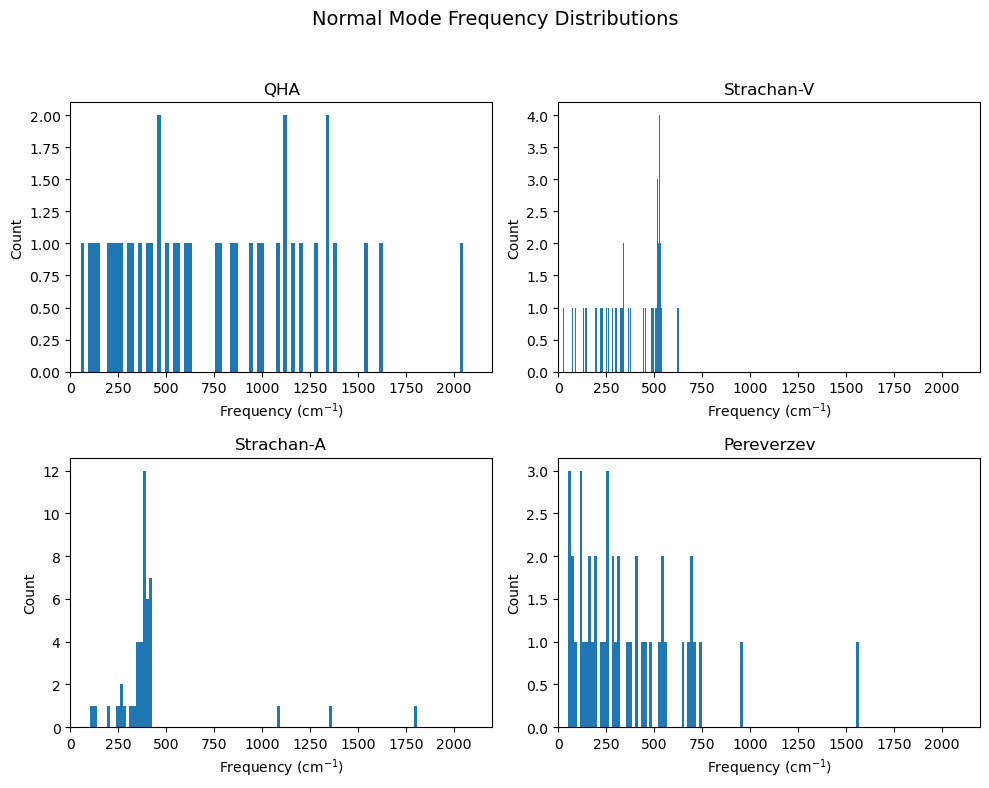

In [10]:
import matplotlib.pyplot as plt

maxv = 2200.0
bb = 100

w1 = results2["frequencies"]
w2 = results3["frequencies"]
w3 = results4["frequencies"]
w4 = results5["frequencies"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)

axes[0, 0].hist(w1[w1 < maxv], bins=bb)
axes[0, 0].set_title("QHA")

axes[0, 1].hist(w2[w2 < maxv], bins=bb)
axes[0, 1].set_title("Strachan-V")

axes[1, 0].hist(w3[w3 < maxv], bins=bb)
axes[1, 0].set_title("Strachan-A")

axes[1, 1].hist(w4[w4 < maxv], bins=bb)
axes[1, 1].set_title("Pereverzev")

for ax in axes.flat:
    ax.set_xlim(0, maxv)
    ax.set_xlabel("Frequency (cm$^{-1}$)")
    ax.set_ylabel("Count")

fig.suptitle("Normal Mode Frequency Distributions", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Exercises 1
[Back to TOC](#TOC)
<a name="1.7"></a>

1. How do results change if the rigid modes are not removed?

2. How do results change if we only use the trajectory alignment instead of the rigid modes removal - consider this function
<a name="align_trajectory-1"></a>

In [11]:
help(md_align.project_out_rigid)

Help on function project_out_rigid in module libra_py.md_align:

project_out_rigid(X_t, R_t, M)
    Remove rigid-body translations and rotations from a snapshot vector
    (coordinates, velocities, or accelerations), assuming the mass vector
    M has length 3N (one mass per Cartesian DOF).
    
    The projection removes the six rigid-body modes for a nonlinear molecule:
        - 3 translational modes
        - 3 rotational modes
    
    Equations:
    
        Translation basis:
            t_alpha = sqrt(m_i) * e_alpha
        Rotation basis:
            r_alpha = sqrt(m_i) * (R_i - R_CM) × e_alpha
        Projected vector:
            X_proj = X - P P^T X
        Mass-weighted covariance matrices:
            K_ij^δr = 1/2 < sqrt(m_i m_j) δr_i δr_j >
            K_ij^v  = 1/2 < sqrt(m_i m_j) v_i v_j >
            K_ij^a  = 1/2 < sqrt(m_i m_j) a_i a_j >
    
    Args:
        X_t : np.ndarray of shape (3*N,)
            Input vector to project (coordinates, velocities, or accelera

## 2. Step-by-step explanation of the procedure
[Back to TOC](#TOC)
<a name="2"></a>

Now, we can look in more details of what's under the hood

Let's read the trajectories and store data in a MATRIX format for future calculations

### 2.1. Reading the trajectory
[Back to TOC](#TOC)
<a name="2.1"></a>
<a name="read_trajectory-1"></a>

In [12]:
help(xyz.read_trajectory)

Help on function read_trajectory in module libra_py.packages.xyz.methods:

read_trajectory(filename, scaling=1.0)
    Read an MD trajectory from an XYZ file using NumPy.
    
    Parameters
    ----------
    filename : str
        Path to the XYZ file containing the MD trajectory.
        Standard XYZ format is assumed:
            nat
            comment
            element  x  y  z
            ...
    
    scaling : float, optional
        How much to scale the raw input data
    
    Returns
    -------
    R : np.ndarray, shape (3*nat, nsteps)
        Cartesian coordinates of all atoms for all time steps,
        ordered as (x1, y1, z1, x2, y2, z2, ...).
    
    E : list of str, length nat
        Atomic symbols (element names), in the order they appear
        in the XYZ file.
    
    Notes
    -----
    - All frames in the XYZ file are read.
    - The array layout (3*nat, nsteps) matches legacy Libra-style
      coordinate storage and is convenient for mass-weighting
      and

In [13]:
R, E = xyz.read_trajectory("coordinates.xyz", scaling=units.Angst)

In [14]:
R.shape

(45, 3001)

In [15]:
len(E)

15

In [16]:
print(R)

[[-0.76155957 -0.75966985 -0.75778012 ... -0.57258697 -0.57636643
  -0.58014588]
 [ 2.05980133  2.05413215  2.04657325 ...  1.92752051  1.93129996
   1.93696914]
 [-1.0110034  -1.0034445  -0.99777532 ... -0.94486299 -0.94297327
  -0.94108354]
 ...
 [-0.2910178  -0.28723835 -0.28156917 ... -0.33259177 -0.32125342
  -0.30991506]
 [-1.4834349  -1.48910408 -1.49477326 ... -1.57981093 -1.57414175
  -1.5703623 ]
 [-1.05257738 -1.0469082  -1.04123902 ... -1.06958491 -1.06580546
  -1.06202601]]


In [17]:
print(E)

['Ti', 'Ti', 'Ti', 'O', 'O', 'O', 'O', 'O', 'O', 'Ti', 'Ti', 'O', 'O', 'O', 'O']


### 2.2. Converting atomic element names to masses
[Back to TOC](#TOC)
<a name="2.2"></a>
<a name="names_to_masses-1"></a>

In [18]:
help(xyz.names_to_masses)

Help on function names_to_masses in module libra_py.packages.xyz.methods:

names_to_masses(E, PT, dtype=<class 'float'>)
    Construct a Cartesian mass vector of length 3N from atomic element names.
    
    Parameters
    ----------
    E : sequence of str, length N
        Atomic symbols (element names), e.g. ["Ti", "O", "O", ...].
    
    PT : dict[str, float]
        Mapping from element name to atomic mass.
        Masses are assumed to be given in atomic mass units (amu).
    
    dtype : data-type, optional
        Data type of the returned array. Default is float.
    
    Returns
    -------
    M : np.ndarray, shape (3*N,)
        Cartesian mass vector, where each atomic mass is repeated
        three times:
            (m1, m1, m1, m2, m2, m2, ..., mN, mN, mN)
    
    Raises
    ------
    KeyError
        If an element in `E` is not found in the mass dictionary `PT`.
    
    Examples
    --------
    >>> PT = {"Ti": 47.9, "O": 16.0}
    >>> E = ["Ti", "O", "O"]
    >>> M

In [19]:
M = xyz.names_to_masses(E, {"Ti":47.9, "O":16.0})

In [20]:
# Scale to atomic units of mass
M = M * units.amu

In [21]:
print(M)

[87944.4 87944.4 87944.4 87944.4 87944.4 87944.4 87944.4 87944.4 87944.4
 29376.  29376.  29376.  29376.  29376.  29376.  29376.  29376.  29376.
 29376.  29376.  29376.  29376.  29376.  29376.  29376.  29376.  29376.
 87944.4 87944.4 87944.4 87944.4 87944.4 87944.4 29376.  29376.  29376.
 29376.  29376.  29376.  29376.  29376.  29376.  29376.  29376.  29376. ]


### 2.3. Computing covariance matrices
[Back to TOC](#TOC)
<a name="2.3"></a>

Let's compute covariances of the coordinates, weighted by the masses
<a name="covariance_matrix-1"></a>

In [22]:
help(nm.covariance_matrix)

Help on function covariance_matrix in module libra_py.normal_modes:

covariance_matrix(X, M, flag=1)
    Compute the mass-weighted covariance matrix of trajectory data.
    
    The covariance matrix is defined as
    
        K_ij = 1/2 ⟨ sqrt(m_i m_j) x_i x_j ⟩
    
    or, if centered (flag = 1),
    
        K_ij = 1/2 ⟨ sqrt(m_i m_j)
                     (x_i - ⟨x_i⟩)(x_j - ⟨x_j⟩) ⟩
    
    where ⟨·⟩ denotes averaging over trajectory steps.
    
    Parameters
    ----------
    X : np.ndarray, shape (ndof, nsteps)
        Trajectory data (e.g., coordinates, velocities, or accelerations).
    
    M : array_like, shape (ndof,)
        Masses associated with each degree of freedom.
    
    flag : {0, 1}, optional
        Controls centering:
        - 0 : use raw data (no mean subtraction)
        - 1 : use fluctuations around the mean (default)
    
    Returns
    -------
    K : np.ndarray, shape (ndof, ndof)
        Mass-weighted covariance matrix averaged over the trajectory.

In [23]:
Kx = nm.covariance_matrix(R, M, flag=1)

In [24]:
print(Kx.shape)
print(Kx)

(45, 45)
[[ 523.01600645   66.25932669  645.71675353 ... -112.56341318
    47.25352315   91.16787438]
 [  66.25932669  878.03151701  939.86868454 ...  178.16735979
   486.68150953  314.40999204]
 [ 645.71675353  939.86868454 2289.55973932 ...  124.1076361
   600.57335894  555.28959446]
 ...
 [-112.56341318  178.16735979  124.1076361  ...  228.42642852
   140.96537925   77.53963142]
 [  47.25352315  486.68150953  600.57335894 ...  140.96537925
   352.55723085  202.75420672]
 [  91.16787438  314.40999204  555.28959446 ...   77.53963142
   202.75420672  234.30007108]]


### 2.4. Solving the eigenvalue problem
[Back to TOC](#TOC)
<a name="2.4"></a>

Compute the eigenvalues and eigenvectors of the position covariance matrix

In [25]:
eigvals_x, eigvecs_x = np.linalg.eigh(Kx)

In [26]:
print(eigvals_x) # in atomic units

[4.79589577e-03 5.10863791e-03 5.23051471e-03 9.28710977e-03
 9.35280779e-03 9.86782110e-03 1.03000731e+01 1.70099722e+01
 1.89144298e+01 2.34737664e+01 2.48443196e+01 2.51865266e+01
 2.75727134e+01 3.01240442e+01 3.23951193e+01 3.47170704e+01
 3.65045054e+01 3.83776856e+01 4.31131148e+01 4.52150273e+01
 5.22812340e+01 5.71401015e+01 6.40638856e+01 7.40642102e+01
 7.89329285e+01 1.14252033e+02 1.26542075e+02 1.45697150e+02
 1.52143096e+02 1.76865379e+02 2.04388923e+02 2.16146853e+02
 2.43848057e+02 2.65539842e+02 3.38260665e+02 4.06724148e+02
 4.70123876e+02 6.50082296e+02 7.58969885e+02 8.78286677e+02
 1.13890234e+03 2.21512646e+03 2.74394871e+03 3.88739440e+03
 1.55472158e+04]


In the next lines, we compute the QHA frequencies and then convert them to $cm^{-1}$ units:

In [27]:
T = 300.0 # K
omega = np.sqrt(units.kB * T/eigvals_x) # since hbar = 1, these are energies of the normal modes in a.u. (Ha)

In [28]:
print(omega)

[4.45079013e-01 4.31240383e-01 4.26186580e-01 3.19839203e-01
 3.18713882e-01 3.10285407e-01 9.60399292e-03 7.47343363e-03
 7.08721092e-03 6.36180854e-03 6.18384266e-03 6.14168934e-03
 5.86992066e-03 5.61584802e-03 5.41542060e-03 5.23118946e-03
 5.10151009e-03 4.97545261e-03 4.69426156e-03 4.58385199e-03
 4.26284037e-03 4.07757052e-03 3.85092753e-03 3.58152335e-03
 3.46930815e-03 2.88363319e-03 2.74002489e-03 2.55356229e-03
 2.49888264e-03 2.31766451e-03 2.15597295e-03 2.09651284e-03
 1.97384177e-03 1.89150345e-03 1.67589280e-03 1.52834713e-03
 1.42156208e-03 1.20889287e-03 1.11881869e-03 1.04004909e-03
 9.13332142e-04 6.54896579e-04 5.88415345e-04 4.94359270e-04
 2.47198409e-04]


In [29]:
# The first 6 modes are unphysical (translational and rotational) - should be disregarded
lambs = omega / units.inv_cm2Ha # conversion to wavenumbers in cm^-1 
print(lambs)

[9.76821748e+04 9.46449894e+04 9.35358235e+04 7.01956013e+04
 6.99486253e+04 6.80988150e+04 2.10780308e+03 1.64020596e+03
 1.55544107e+03 1.39623590e+03 1.35717745e+03 1.34792599e+03
 1.28828050e+03 1.23251879e+03 1.18853068e+03 1.14809719e+03
 1.11963626e+03 1.09197023e+03 1.03025680e+03 1.00602504e+03
 9.35572125e+02 8.94910667e+02 8.45168982e+02 7.86042431e+02
 7.61414390e+02 6.32875407e+02 6.01357472e+02 5.60434238e+02
 5.48433611e+02 5.08661390e+02 4.73174695e+02 4.60124893e+02
 4.33202085e+02 4.15131169e+02 3.67810767e+02 3.35428692e+02
 3.11992414e+02 2.65317575e+02 2.45548857e+02 2.28261171e+02
 2.00450408e+02 1.43731158e+02 1.29140420e+02 1.08497788e+02
 5.42530146e+01]


### 2.5. Sorting frequencies and correspondingly the eigenvectors  
[Back to TOC](#TOC)
<a name="2.5"></a>

In [30]:
idx = np.argsort(lambs)
lambs_sorted = lambs[idx]
eigvecs_sorted = eigvecs_x[:, idx]

In [31]:
print(lambs_sorted)

[5.42530146e+01 1.08497788e+02 1.29140420e+02 1.43731158e+02
 2.00450408e+02 2.28261171e+02 2.45548857e+02 2.65317575e+02
 3.11992414e+02 3.35428692e+02 3.67810767e+02 4.15131169e+02
 4.33202085e+02 4.60124893e+02 4.73174695e+02 5.08661390e+02
 5.48433611e+02 5.60434238e+02 6.01357472e+02 6.32875407e+02
 7.61414390e+02 7.86042431e+02 8.45168982e+02 8.94910667e+02
 9.35572125e+02 1.00602504e+03 1.03025680e+03 1.09197023e+03
 1.11963626e+03 1.14809719e+03 1.18853068e+03 1.23251879e+03
 1.28828050e+03 1.34792599e+03 1.35717745e+03 1.39623590e+03
 1.55544107e+03 1.64020596e+03 2.10780308e+03 6.80988150e+04
 6.99486253e+04 7.01956013e+04 9.35358235e+04 9.46449894e+04
 9.76821748e+04]


### 2.6. Compute the Cartesian normal modes 
[Back to TOC](#TOC)
<a name="2.6"></a>

<a name="normal_modes_from_eigenvectors-1"></a>

In [32]:
help(nm.normal_modes_from_eigenvectors)

Help on function normal_modes_from_eigenvectors in module libra_py.normal_modes:

normal_modes_from_eigenvectors(eta, M)
    Convert mass-weighted eigenvectors to Cartesian normal modes.
    
    The transformation is
    
        Δx = M^{-1/2} η
    
    where:
        - η are mass-weighted eigenvectors
        - M is the Cartesian mass vector
    
    Parameters
    ----------
    eta : np.ndarray, shape (ndof, nmodes) or (ndof,)
        Mass-weighted eigenvectors, typically obtained from
        diagonalizing a mass-weighted covariance or Hessian matrix.
    
    M : array_like, shape (ndof,)
        Cartesian mass vector (each atomic mass repeated for x, y, z).
    
    Returns
    -------
    dx : np.ndarray, shape (ndof, nmodes) or (ndof,)
        Cartesian normal modes.
    
    Notes
    -----
    - No normalization is enforced; normalization conventions depend
      on whether the eigenvectors came from a covariance or Hessian.
    - This operation is equivalent to left-multip

In [33]:
dx = nm.normal_modes_from_eigenvectors(eigvecs_sorted, M)

Note that the original eigenvectors are orthonormal:

In [34]:
print(eigvecs_sorted.T @ eigvecs_sorted)

[[ 1.00000000e+00 -3.72721583e-17 -1.92057866e-17 ... -1.41081618e-17
   3.16586355e-17 -4.71871438e-18]
 [-3.72721583e-17  1.00000000e+00 -3.22220239e-17 ... -9.44759793e-18
   2.36221044e-17  1.92768263e-17]
 [-1.92057866e-17 -3.22220239e-17  1.00000000e+00 ... -8.22951325e-17
  -3.92248699e-17  3.50870662e-17]
 ...
 [-1.41081618e-17 -9.44759793e-18 -8.22951325e-17 ...  1.00000000e+00
  -1.64658315e-16 -5.89028868e-16]
 [ 3.16586355e-17  2.36221044e-17 -3.92248699e-17 ... -1.64658315e-16
   1.00000000e+00 -3.67293813e-17]
 [-4.71871438e-18  1.92768263e-17  3.50870662e-17 ... -5.89028868e-16
  -3.67293813e-17  1.00000000e+00]]


but the Cartesian normal modes aren't orthonormal:

In [35]:
print(dx.T @ dx)

[[ 2.10499756e-05  2.41479170e-06  1.20198450e-06 ...  2.06413077e-07
  -1.33512651e-06  1.26816580e-06]
 [ 2.41479170e-06  2.25403788e-05  5.79380447e-07 ...  4.04031891e-07
  -7.27011295e-07  3.89392488e-07]
 [ 1.20198450e-06  5.79380447e-07  2.25575231e-05 ... -1.26598929e-07
  -1.40774296e-06  1.01866076e-06]
 ...
 [ 2.06413077e-07  4.04031891e-07 -1.26598929e-07 ...  3.17859170e-05
  -4.98392365e-08  1.56914737e-07]
 [-1.33512651e-06 -7.27011295e-07 -1.40774296e-06 ... -4.98392365e-08
   3.18859473e-05  1.04398121e-07]
 [ 1.26816580e-06  3.89392488e-07  1.01866076e-06 ...  1.56914737e-07
   1.04398121e-07  3.22337107e-05]]


### 2.7. Manipulating eigenvectors
[Back to TOC](#TOC)
<a name="2.7"></a>

In [36]:
print(dx)
print(dx[:, 0]) # first eigenvector - lowest frequency
print(dx[:, 44]) # last eigenvector - one of the trivial modes

[[ 1.97472004e-04 -1.02525782e-03 -7.36791591e-05 ...  2.58608694e-04
   2.95825240e-05  4.77097699e-05]
 [ 6.84018699e-04  3.19686058e-04  1.10539724e-04 ...  5.53910473e-05
   7.18599434e-05  1.77513003e-04]
 [ 1.08739268e-03 -1.18425716e-03  1.50159260e-04 ...  1.31384798e-05
   2.27246238e-05  3.96088117e-04]
 ...
 [ 2.40734117e-04  6.08021752e-04  6.50849816e-04 ... -4.70970650e-04
   4.99010776e-04 -2.33716570e-04]
 [ 7.46990040e-04  3.56549691e-04  1.33045277e-04 ...  2.41809693e-04
   1.43276236e-04  6.82404669e-04]
 [ 5.85242812e-04 -1.12941079e-04 -1.16903984e-05 ... -1.42038133e-04
  -4.11137503e-04 -8.48649448e-04]]
[ 1.97472004e-04  6.84018699e-04  1.08739268e-03  3.34270789e-04
  6.71598935e-04  5.29135812e-04  9.11319598e-05 -2.56636556e-04
  2.50612658e-05  3.27322964e-04  4.39186929e-04 -5.32968999e-04
 -1.74573884e-04  9.44419424e-05  9.60309429e-05  1.21944016e-03
 -7.82452060e-04  1.16470524e-04  1.66791905e-03  3.42719599e-04
  1.15015203e-03 -2.54998190e-04 -2.495

In [37]:
dx[:,44].reshape(45,1)

array([[ 4.77097699e-05],
       [ 1.77513003e-04],
       [ 3.96088117e-04],
       [-3.34560282e-05],
       [-2.76337021e-04],
       [-3.19329555e-04],
       [-7.40429255e-05],
       [-1.65237505e-04],
       [-4.72538698e-04],
       [-1.31745840e-04],
       [-8.58080444e-05],
       [-7.33354454e-04],
       [-2.60591293e-04],
       [-1.51377015e-03],
       [-2.28225285e-03],
       [ 1.21640344e-04],
       [-8.42387704e-04],
       [ 1.95550041e-04],
       [ 2.47969513e-04],
       [-1.19681649e-03],
       [ 6.76833538e-04],
       [ 1.14637137e-04],
       [ 3.44666981e-04],
       [ 8.58762642e-04],
       [ 2.06114836e-04],
       [ 1.18513690e-03],
       [ 1.86272177e-03],
       [ 7.58324608e-05],
       [ 6.48686745e-06],
       [ 4.47791410e-04],
       [-8.79719319e-06],
       [ 2.43188917e-04],
       [ 1.22240802e-04],
       [-3.83863807e-04],
       [ 6.18232618e-04],
       [-1.69884303e-03],
       [ 7.84506887e-05],
       [ 1.54757523e-03],
       [ 1.3

### 2.8. Writing coordinates and normal mode vectors into XYZ files
[Back to TOC](#TOC)
<a name="2.8"></a>
<a name="write_trajectory-1"></a>

In [38]:
help(xyz.write_trajectory)

Help on function write_trajectory in module libra_py.packages.xyz.methods:

write_trajectory(filename, R, E, scaling=1.0)
    Write a trajectory to an XYZ-format file.
    
    Args:
        filename : str
            Path to the output XYZ file.
        R : np.ndarray of shape (3*N, nsteps)
            Cartesian coordinates for all atoms and timesteps.
        E : list of str, length N
            Atom labels (elements) for each atom.
        scaling : float, default 1.0
            How much scale the input data before writing to file
    
    Usage:
        >>> R, E = read_trajectory("coords.xyz", scaling = units.Angst) # Angstrom to Bohr
        >>> write_trajectory("out.xyz", R, E, scaling = 1.0/units.Angst) # Bohr to Angstrom



For saving arrays to the XYZ file, the should be shaped as 2D arrays.

We can store one normal mode like this

In [39]:
xyz.write_trajectory("nm_44.xyz", dx[:,44].reshape(45,1), E, scaling=1.0/units.Angst)

Or we can save all the normal modes like this:

In [40]:
xyz.write_trajectory("all_nm.xyz", dx, E, scaling=1.0/units.Angst)

Or we can save one frame out of the trajectory

In [41]:
xyz.write_trajectory("r0.xyz", R[:,0].reshape(45,1), E, scaling=1.0/units.Angst)

### 2.9. Writing all normal modes into an ".nmd" file understood by VMD
[Back to TOC](#TOC)
<a name="2.9"></a>
<a name="write_nmd-1"></a>

In [42]:
help(nm.write_nmd)

Help on function write_nmd in module libra_py.normal_modes:

write_nmd(filename, R_eq, modes, atom_names, masses=None, eigenvalues=None, title='Normal modes')
    Write a ProDy/VMD-compatible NMD (Normal Mode Data) file.
    
    This implementation follows the official ProDy NMD specification:
    http://www.bahargroup.org/prody/manual/reference/dynamics/nmdfile.html
    
    Parameters
    ----------
    filename : str
        Output .nmd file.
    
    R_eq : ndarray, shape (3N,)
        Equilibrium Cartesian coordinates (e.g., Å).
    
    modes : ndarray, shape (3N, nmodes)
        Normal mode eigenvectors. If masses are provided, these are
        assumed to be mass-weighted eigenvectors η.
    
    atom_names : list[str], length N
        Atom or element names (written as `atomnames`).
    
    masses : ndarray, shape (3N,), optional
        Cartesian mass vector. If provided, modes are converted via:
            Δx = M^{-1/2} η
    
    eigenvalues : ndarray, shape (nmodes,), o

As an example, we will save the QHA results computed above:

In [43]:
nm.write_nmd("modes.nmd", R[:,0]/units.Angst, 
             results2["modes_cart"]/units.Angst, 
             E, masses=None, eigenvalues=results2["frequencies"])

Wrote NMD file: modes.nmd


### 2.10. Generating normal mode trajectories
[Back to TOC](#TOC)
<a name="2.10"></a>

As an alternative approach to visualize normal modes, we can also use the function
<a name="visualize_modes-1"></a>

In [44]:
help(nm.visualize_modes)

Help on function visualize_modes in module libra_py.normal_modes:

visualize_modes(E, R, eta, M, frequencies, params)
    Visualize selected normal modes by generating XYZ trajectories.
    
    The visualization is performed by constructing a synthetic trajectory
    corresponding to sinusoidal motion along selected normal modes.
    
    Args:
        E (list of str, length N):
            Atom names.
    
        R (ndarray, shape (3N,)):
            Reference Cartesian geometry in atomic units.
    
        eta (ndarray, shape (3N, 3N)):
            Mass-weighted normal-mode eigenvectors.
    
        M (ndarray, shape (3N,)):
            Masses of Cartesian degrees of freedom (in a.u.).
    
        frequencies (ndarray, shape (3N,)):
            Mode frequencies in cm^{-1}.
    
        params (dict):
            Visualization parameters:
                - "scale" (float): mode amplification factor
                - "print_modes" (list[int]): indices of modes to visualize
       

In [45]:
results2.keys()

dict_keys(['eigvals', 'eigvecs', 'modes_cart', 'frequencies'])

In [46]:
R[:,0].shape

(45,)

In [47]:
nm.visualize_modes(E, R[:,0]/units.Angst, 
                   results2["eigvecs"], M,
                   results2["frequencies"],
                   {"scale":1000.0, "print_modes":[7, 43, 44], 
                    "prefix":"qha_", "nperiods":1, "nsteps":25 }
                  )